# The atlas, milestone M0

A local prototype of the agent-first LMFDB described in `design/lmfdb-for-agents.md`: immutable Parquet shards, manifests, certificates, and a status for every row. Everything below is what an agent would do: discover tables, query them with DuckDB, check a certificate, recompute a row, and evaluate a claim over a whole table.

In [1]:
import json, os, sys, duckdb
sys.path.insert(0, os.path.expanduser('~/sagebrush/atlas'))
import atlas
ROOT = '/home/user/data/atlas'
tables = [('mf', 'rational_newforms_wt2'), ('mf', 'newform_orbits_wt2'), ('ec', 'curves'), ('lmfdb', 'mf_newforms_wt2')]
for kind, table in tables:
    m = atlas.manifest(ROOT, kind, table)
    size = sum(s['bytes'] for s in m['shards'])
    print(f"{kind}/{table}: {m['rows']:,} rows, {len(m['shards'])} shards, {size/1e6:.1f} MB; "
          + ', '.join(f'{k} {v}' for k, v in m['status_counts'].items() if v))

mf/rational_newforms_wt2: 38,042 rows, 4 shards, 5.7 MB; checked 38042
mf/newform_orbits_wt2: 5,951 rows, 3 shards, 4.0 MB; checked 5951
ec/curves: 64,687 rows, 4 shards, 1.6 MB; checked 64687
lmfdb/mf_newforms_wt2: 128,055 rows, 7 shards, 27.0 MB; checked 41530, imported 86525


## Query with DuckDB

Shards are verified against their SHA-256 before use. Every elliptic curve is linked to its newform by point counts (modularity, checked row by row).

In [2]:
con = duckdb.connect()
for kind, table in tables:
    atlas.duckdb_view(con, ROOT, kind, table, f'{kind}_{table}')
con.sql("""select c.label as curve, c.ainvs, c.rank, n.label as newform, n.ap[1:6] as a2_to_a13
          from ec_curves c join mf_rational_newforms_wt2 n on c.newform = n.label
          where c.conductor in (11, 37, 389, 5077) and c.label like '%1' order by c.conductor""").show()

┌─────────┬────────────────────────────┬───────┬────────────┬──────────────────────────┐
│  curve  │           ainvs            │ rank  │  newform   │        a2_to_a13         │
│ varchar │          int64[]           │ int32 │  varchar   │         int32[]          │
├─────────┼────────────────────────────┼───────┼────────────┼──────────────────────────┤
│ 11.a1   │ [0, -1, 1, -7820, -263580] │     0 │ 11.2.a.a   │ [-2, -1, 1, -2, NULL, 4] │
│ 37.a1   │ [0, 0, 1, -1, 0]           │     1 │ 37.2.a.a   │ [-2, -3, -2, -1, -5, -2] │
│ 37.b1   │ [0, 1, 1, -1873, -31833]   │     0 │ 37.2.a.b   │ [0, 1, 0, -1, 3, -4]     │
│ 389.a1  │ [0, 1, 1, -2, 0]           │     2 │ 389.2.a.a  │ [-2, -2, -3, -5, -4, -3] │
│ 5077.a1 │ [0, 0, 1, -7, 6]           │     3 │ 5077.2.a.a │ [-2, -3, -4, -4, -6, -4] │
└─────────┴────────────────────────────┴───────┴────────────┴──────────────────────────┘



## Certificates

Each row points to a certificate: what is claimed, the method, the checks, and a recipe to recompute.

In [3]:
sha = con.sql("select certificate from mf_rational_newforms_wt2 where label = '5077.2.a.a'").fetchone()[0]
print(json.dumps(atlas.certificate(ROOT, sha), indent=2)[:1500])

{
  "checks": [
    "equal to Cremona's ecdata aplist (p < 100) for all isogeny classes",
    "equal to LMFDB mf_newforms traces (p < 1000)",
    "equal to point counts by sagebrush-ap on an LMFDB curve of the class (p < 1000)",
    "Hasse bound at every p"
  ],
  "claim": "a_p (p < 1000, p not dividing N) of every rational weight-2 newform on Gamma0(N), 11 <= N <= 9999",
  "created": "2026-10-03T04:56:36+00:00",
  "method": "Split the dual of the sign +1 modular symbols mod 2147483629 by integer T_q eigenvalues in the Hasse range; old systems explained by lower levels with multiplicity d(N/M); a_p = psi(T_p x)/psi(x) from one Heilbronn sum per prime (sagebrush-modsym newforms.rs).",
  "recipe": {
    "command": "cd engine && cargo run --release -p sagebrush-modsym --example rational_table -- OUT.jsonl 11 9999",
    "commit": "69a53640e925fd385e90689d620787a52abd0d3f",
    "repository": "https://github.com/sagemathinc/sagebrush"
  }
}


## Recompute a row and compare

An agent that doubts a value recomputes it. Here, from modular symbols and from point counting, with Sagebrush.

In [4]:
from sagebrush import modsym, ap
row = con.sql("select label, level, ap from mf_rational_newforms_wt2 where label = '5077.2.a.a'").fetchone()
primes = [p for p in range(2, 1000) if all(p % d for d in range(2, int(p**0.5) + 1))]
stored = {p: a for p, a in zip(primes, row[2]) if a is not None}
fresh = dict(modsym.rational_newforms(row[1], 999)[0])
curve = con.sql("select ainvs from ec_curves where newform = '5077.2.a.a' limit 1").fetchone()[0]
counted = dict(ap.aplist(curve, 999))
print('stored == recomputed by modular symbols:', stored == fresh)
print('stored == point counts:', all(counted[p] == a for p, a in stored.items()))

stored == recomputed by modular symbols: True
stored == point counts: True


## A claim over a whole table

The Hasse bound $|a_p|\le 2\sqrt p$ for every rational newform of level $\le 9999$ and every $p<1000$, as one query.

In [5]:
total = con.sql("select count(*) from (select unnest(ap) as a from mf_rational_newforms_wt2) where a is not null").fetchone()[0]
viol = con.execute("""select count(*) from (select unnest(ap) as a, unnest(?) as p from mf_rational_newforms_wt2)
                     where a is not null and a * a > 4 * p""", [primes]).fetchone()[0]
print(f'{total:,} values of a_p checked; violations of the Hasse bound: {viol}')

6,272,921 values of a_p checked; violations of the Hasse bound: 0


## Murmurations

The average of $a_p$ over rational newforms with level in $[5000, 10000)$, by parity of the analytic rank (He, Lee, Oliver and Pozdnyakov). Computed from the table in one query.

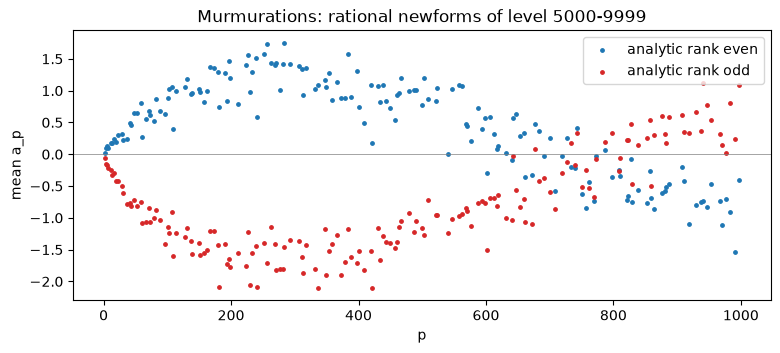

In [6]:
import matplotlib.pyplot as plt
df = con.execute("""select analytic_rank % 2 as parity, p, avg(a) as mean_ap, count(*) as n
    from (select analytic_rank, unnest(ap) as a, unnest(?) as p from mf_rational_newforms_wt2 where level >= 5000)
    where a is not null group by all order by p""", [primes]).df()
fig, ax = plt.subplots(figsize=(9, 3.5))
for parity, colour in [(0, 'tab:blue'), (1, 'tab:red')]:
    d = df[df.parity == parity]
    ax.scatter(d.p, d.mean_ap, s=6, c=colour, label=f'analytic rank {"even" if parity == 0 else "odd"}')
ax.axhline(0, c='grey', lw=0.5); ax.set_xlabel('p'); ax.set_ylabel('mean a_p'); ax.legend()
ax.set_title('Murmurations: rational newforms of level 5000-9999')
plt.savefig('murmurations_m0.png', dpi=120, bbox_inches='tight'); plt.show()

## Compact exact coefficients for orbits LMFDB does not store

LMFDB stores $q$-expansions only up to dimension 20. Here every orbit of level $\le 1000$ has exact integer coordinates of $a_p$ (Stein's representation after HNF + LLL).

In [7]:
con.sql("""select label, dim, len(ap_coordinates) as primes, trace_ap[1:4] as tr_a2_to_a7
   from mf_newform_orbits_wt2 where dim >= 50 order by dim desc""").show()
row = con.sql("select ap_coordinates from mf_newform_orbits_wt2 where label = '971.2.a.b'").fetchone()[0]
bits = sum(abs(int(x)).bit_length() + 1 for v in row for x in v)
print(f'971.2.a.b (dim 55): {bits / len(row):.0f} bits per a_p; a_2 coordinates: {row[0]}')

┌───────────┬───────┬────────┬────────────────┐
│   label   │  dim  │ primes │  tr_a2_to_a7   │
│  varchar  │ int32 │ int64  │    int64[]     │
├───────────┼───────┼────────┼────────────────┤
│ 971.2.a.b │    55 │    167 │ [4, 4, 8, 14]  │
│ 983.2.a.b │    54 │    167 │ [8, 6, 7, 31]  │
│ 911.2.a.c │    53 │    167 │ [2, 6, 10, 14] │
│ 839.2.a.b │    51 │    167 │ [4, 4, 6, 19]  │
│ 887.2.a.c │    51 │    167 │ [4, 11, 8, 23] │
│ 941.2.a.b │    50 │    167 │ [3, 12, 6, 23] │
└───────────┴───────┴────────┴────────────────┘

971.2.a.b (dim 55): 106 bits per a_p; a_2 coordinates: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0]
